In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy  as np
import math, json, os
pd.set_option('display.max_columns', None)

In [14]:
OPTIONS  = json.loads(open('info.json', 'rb').read())
TARGETS  = OPTIONS['target_var']
N_STATES = OPTIONS['n_states']
dt = OPTIONS['dt']

TEST    = json.loads(open('../../info.json', 'r').read()).get('test', 1)
SOURCE  = f'../../Dataset/test{TEST}/files/data.csv'
DATASET = 'Backup/target.csv'

print('SOURCE:', SOURCE)
OPTIONS

SOURCE: ../../Dataset/test1/files/data.csv


{'target_var': ['pitch', 'roll'],
 'seevar': 'wx',
 'n_states': 30,
 'k_cv': 5,
 'model': 'linear_regression',
 'n_iter': 15000,
 'dt': 0.1}

# IMPORTANDO DADOS
Saída do ensaio de pêndulo: cada amostra traz a IMU em teste (`target_`) e a MRU de referência (`ref_`) já alinhadas no mesmo instante.

In [15]:
df = pd.read_csv(SOURCE)
print(len(df), 'linhas')
df.head()

1801 linhas


,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.59,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.54,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.46,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.17,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.51,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821


# DEFASAGEM
- Atraso da IMU em teste contra a MRU de referência: pico da correlação cruzada do roll, só no trecho em movimento (`static` falso)
- Todas as colunas `target_` andam juntas, sem atravessar o buraco da gravação; as amostras que ficam sem par saem

In [16]:
# ATRASO DA IMU EM TESTE CONTRA A REFERÊNCIA PELO PICO DA CORRELAÇÃO CRUZADA
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df, var):
        if df.empty:
            return 0

        x = df[self.target + var]
        y = df[self.reference + var]

        correlation = np.correlate(y - y.mean(), x - x.mean(), mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        return lags[np.argmax(correlation)]

    def set(self, df, lag):
        columns = df.filter(regex=f'^{self.target}').columns
        step    = df.time.diff()
        block   = (step > 1.5*step.median()).cumsum()    # O DESLOCAMENTO NÃO ATRAVESSA O BURACO DA GRAVAÇÃO

        df[columns] = df.groupby(block)[columns].shift(lag)
        return df.dropna(subset=columns).reset_index(drop=True)


phaser = Phaser('target_', 'ref_')
lag    = phaser.get(df[~df.static], 'roll')
df     = phaser.set(df, lag)
print('defasagem:', lag, 'amostras |', len(df), 'linhas')

defasagem: 0 amostras | 1801 linhas


# RENOMEANDO COLUNAS

In [17]:
SENSORS = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']
ANGLES  = ['pitch', 'roll', 'yaw']

# ENTRADA SAI DA IMU EM TESTE, RÓTULO SAI DA MRU DE REFERÊNCIA
columns = {f'target_{var}': var for var in SENSORS} | {f'ref_{var}': var for var in ANGLES}
df = df[['time', 'static'] + list(columns)].rename(columns=columns)
df

,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...,...,...,...
1796,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493,1.645535,-92.131613,6.371291
1797,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338,1.644962,-92.131613,6.371291
1798,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588,1.645535,-92.131613,6.377020
1799,279.8,True,0.222170,9.755871,-0.409330,-0.01801,-0.00522,0.04660,1.644962,-92.131613,6.377020


# PERÍODO DE AMOSTRAGEM
- Verificando a distribuição do período para verificar número de outliers

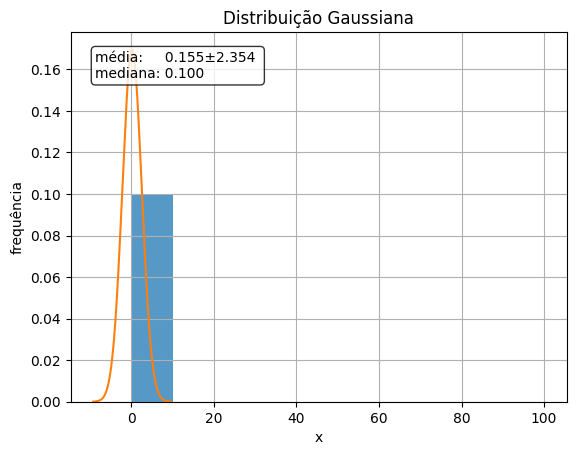

2799 amostras na grade de 0.1 s


,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...,...,...,...
2794,279.4,True,0.269369,9.760873,-0.416959,-0.09321,0.25104,-0.21920,1.644962,-92.131613,6.371291
2795,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493,1.645535,-92.131613,6.371291
2796,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338,1.644962,-92.131613,6.371291
2797,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588,1.645535,-92.131613,6.377020


In [18]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)

    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

# GRADE E LEITURAS ARREDONDADAS NA MESMA CASA: SEM ISSO O RUÍDO DE FLOAT (1e-14) FAZ O merge_asof SEGURAR A AMOSTRA ANTERIOR
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = (df[key] - df[key].iloc[0]).round(10)

    n = int(np.floor(df[key].iloc[-1] / dt)) + 1
    newAxis = np.round(np.linspace(0, dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    return pd.merge_asof(target, df, on=key, direction='backward')


time = df.time.diff()[1:].to_numpy()

gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
print(len(df), 'amostras na grade de', dt, 's')
df

# VISUALIZAÇÃO DOS DADOS

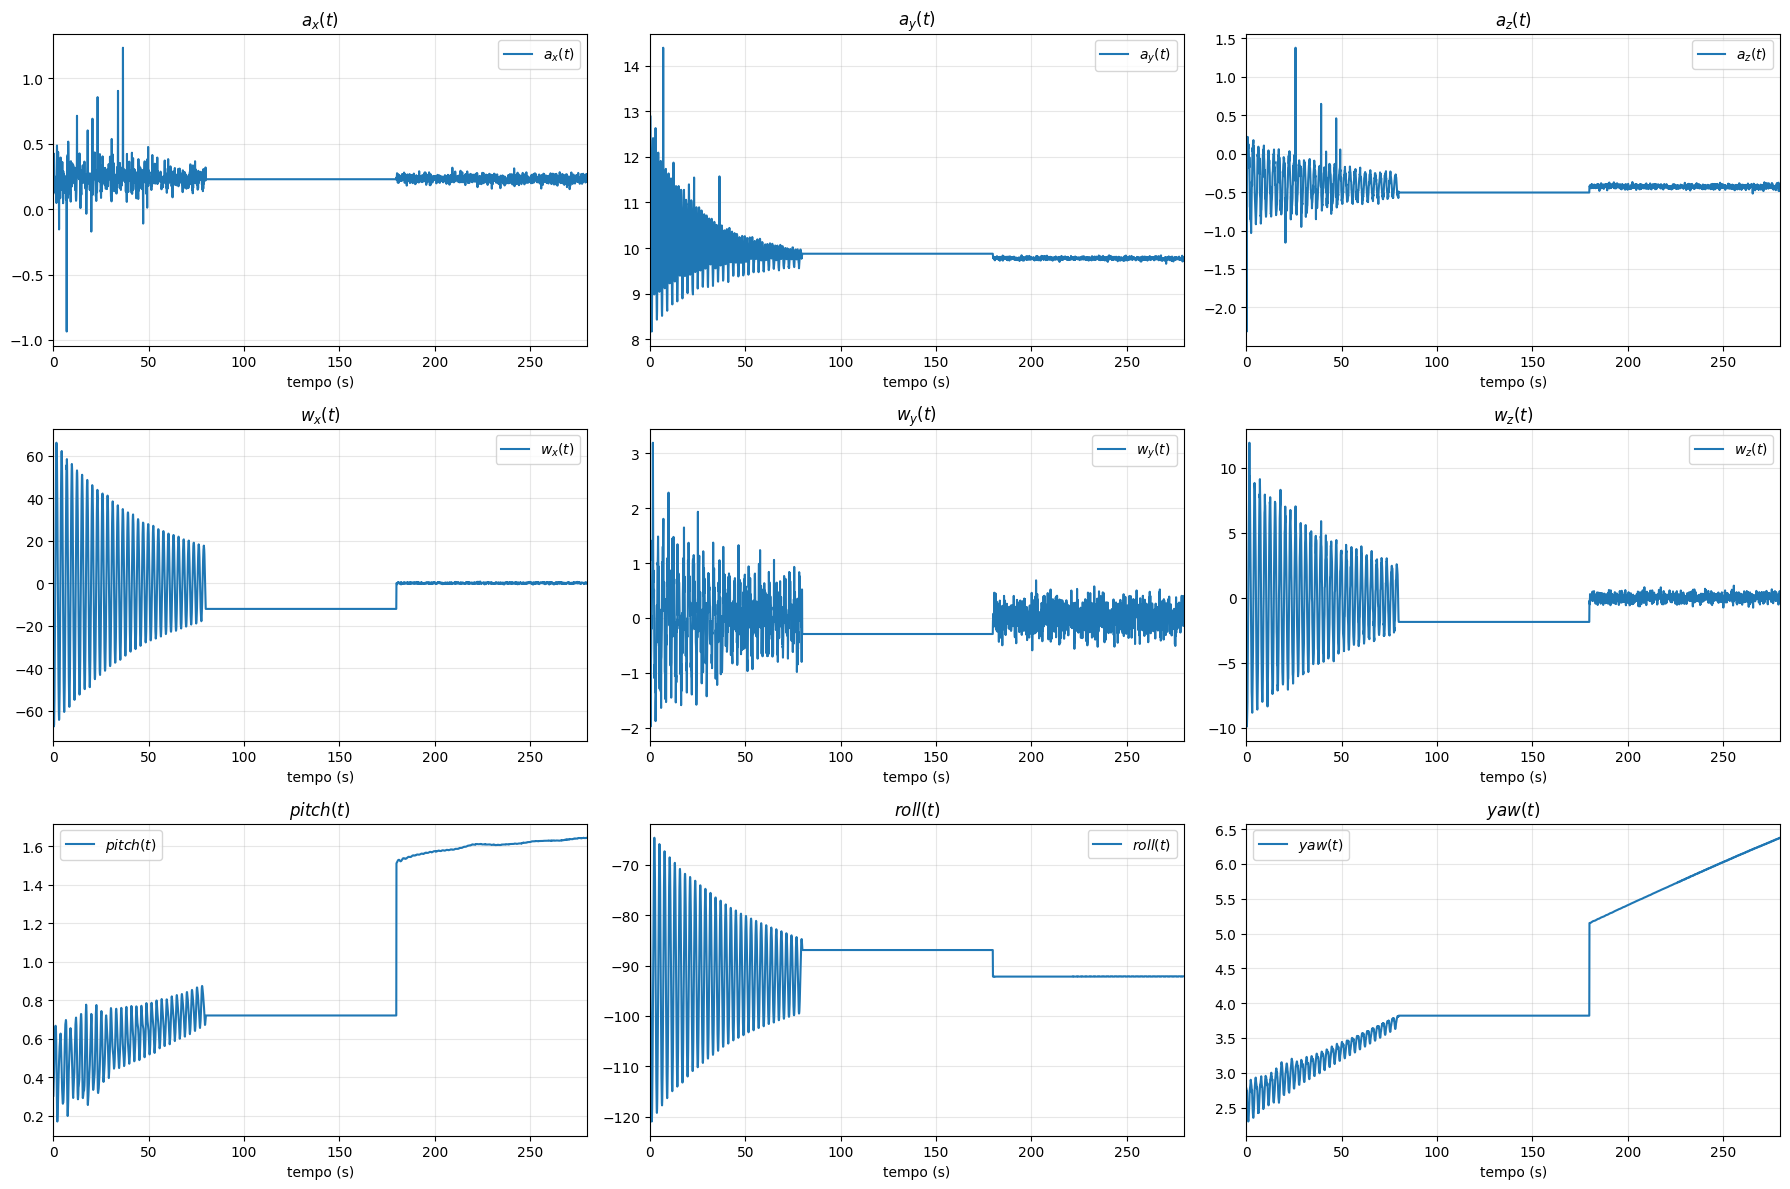

In [19]:
# GRADE DE SUBPLOTS RECORTADA POR FRAÇÃO DO TEMPO TOTAL
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)

    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])

    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)

        plt.subplot(numRows, numCols, i+1)
        plt.plot(time[mask], values[mask], label=key)

        plt.xlim(start_time, end_time)
        if yLim: plt.ylim(yLim)
        plt.title(key); plt.xlabel('tempo (s)')
        plt.grid(alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.show()


# PAINEL PADRÃO: GIROSCÓPIO, ACELERÔMETRO E ATITUDE DE REFERÊNCIA
def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# SALVANDO DADOS

In [20]:
os.makedirs('Backup', exist_ok=True)

df.to_csv(DATASET, index=None)
pd.read_csv(DATASET).head()

,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720


# VALORES PASSADOS
- Fora as linhas que a grade repetiu dentro do buraco da gravação: eram 55% do treino

In [21]:
df = df[(df[SENSORS].diff() != 0).any(axis=1)].reset_index(drop=True)    # FORA O BURACO QUE A GRADE PREENCHEU: 999 LINHAS REPETIDAS, 55% DO TREINO
print(len(df), 'linhas')
df.describe()

1800 linhas


,time,ax,ay,az,wx,wy,wz,pitch,roll,yaw
count,1800.00000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,145.45000,0.233662,9.887098,-0.414362,-0.110539,0.010999,-0.007866,1.160627,-92.115475,4.625742
std,98.02825,0.068377,0.453528,0.165811,18.323658,0.443921,2.617892,0.504132,7.774347,1.333315
min,0.00000,-0.935613,8.169606,-2.312996,-67.532520,-1.978450,-9.920990,0.170913,-120.951391,2.299280
25%,44.97500,0.211480,9.752412,-0.453070,-0.347303,-0.193785,-0.378135,0.660620,-92.188909,3.267005
50%,189.85000,0.232320,9.780049,-0.427295,-0.000365,0.010835,0.006265,1.553862,-92.188909,5.277228
75%,234.82500,0.252730,9.855276,-0.396993,0.362387,0.218927,0.398352,1.611301,-92.131613,5.844170
max,279.80000,1.235275,14.390033,1.375491,66.068610,3.193530,11.926620,1.645535,-64.629639,6.377020


In [22]:
# JANELA DESLIZANTE: y(n), y(n-1) ... y(n-N+1) COMO COLUNAS, SEM ATRAVESSAR O BURACO ENTRE TRECHOS
def getStates(df, key, var='y', n=10):
    table   = df.copy()
    segment = (table.time.diff() > 1.5*dt).cumsum()
    table[f'{var}'] = table[key]

    for i in range(1, n):
        table[f'{var}(n-{i})'] = table[key].groupby(segment).shift(i)

    columns = [f'{var}'] + [f'{var}(n-{i})' for i in range(1, n)]
    return table[columns]


print('n_states:', N_STATES)
xData = pd.concat([getStates(df, var, var=var, n=N_STATES) for var in ['wx', 'wy', 'wz', 'ax', 'ay', 'az']], axis=1)
xData

n_states: 30


,wx,wx(n-1),wx(n-2),wx(n-3),wx(n-4),wx(n-5),wx(n-6),wx(n-7),wx(n-8),wx(n-9),wx(n-10),wx(n-11),wx(n-12),wx(n-13),wx(n-14),wx(n-15),wx(n-16),wx(n-17),wx(n-18),wx(n-19),wx(n-20),wx(n-21),wx(n-22),wx(n-23),wx(n-24),wx(n-25),wx(n-26),wx(n-27),wx(n-28),wx(n-29),wy,wy(n-1),wy(n-2),wy(n-3),wy(n-4),wy(n-5),wy(n-6),wy(n-7),wy(n-8),wy(n-9),wy(n-10),wy(n-11),wy(n-12),wy(n-13),wy(n-14),wy(n-15),wy(n-16),wy(n-17),wy(n-18),wy(n-19),wy(n-20),wy(n-21),wy(n-22),wy(n-23),wy(n-24),wy(n-25),wy(n-26),wy(n-27),wy(n-28),wy(n-29),wz,wz(n-1),wz(n-2),wz(n-3),wz(n-4),wz(n-5),wz(n-6),wz(n-7),wz(n-8),wz(n-9),wz(n-10),wz(n-11),wz(n-12),wz(n-13),wz(n-14),wz(n-15),wz(n-16),wz(n-17),wz(n-18),wz(n-19),wz(n-20),wz(n-21),wz(n-22),wz(n-23),wz(n-24),wz(n-25),wz(n-26),wz(n-27),wz(n-28),wz(n-29),ax,ax(n-1),ax(n-2),ax(n-3),ax(n-4),ax(n-5),ax(n-6),ax(n-7),ax(n-8),ax(n-9),ax(n-10),ax(n-11),ax(n-12),ax(n-13),ax(n-14),ax(n-15),ax(n-16),ax(n-17),ax(n-18),ax(n-19),ax(n-20),ax(n-21),ax(n-22),ax(n-23),ax(n-24),ax(n-25),ax(n-26),ax(n-27),ax(n-28),ax(n-29),ay,ay(n-1),ay(n-2),ay(n-3),ay(n-4),ay(n-5),ay(n-6),ay(n-7),ay(n-8),ay(n-9),ay(n-10),ay(n-11),ay(n-12),ay(n-13),ay(n-14),ay(n-15),ay(n-16),ay(n-17),ay(n-18),ay(n-19),ay(n-20),ay(n-21),ay(n-22),ay(n-23),ay(n-24),ay(n-25),ay(n-26),ay(n-27),ay(n-28),ay(n-29),az,az(n-1),az(n-2),az(n-3),az(n-4),az(n-5),az(n-6),az(n-7),az(n-8),az(n-9),az(n-10),az(n-11),az(n-12),az(n-13),az(n-14),az(n-15),az(n-16),az(n-17),az(n-18),az(n-19),az(n-20),az(n-21),az(n-22),az(n-23),az(n-24),az(n-25),az(n-26),az(n-27),az(n-28),az(n-29)
0,-47.92960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.16726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.92455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.194623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.733555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.614769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-58.13591,-47.92960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.05996,-1.16726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.13221,-6.92455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.294719,0.194623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.618576,10.733555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.532550,-0.614769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-67.53252,-58.13591,-47.92960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.95110,-1.05996,-1.16726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.42212,-8.13221,-6.92455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.256924,0.294719,0.194623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.899422,11.618576,10.733555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.312996,-0.532550,-0.614769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-67.39252,-67.53252,-58.13591,-47.92960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
df = pd.concat([df.time, xData, df[TARGETS]], axis=1).dropna().reset_index(drop=True)
df.to_csv('Backup/model.csv', index=None)
df

,time,wx,wx(n-1),wx(n-2),wx(n-3),wx(n-4),wx(n-5),wx(n-6),wx(n-7),wx(n-8),wx(n-9),wx(n-10),wx(n-11),wx(n-12),wx(n-13),wx(n-14),wx(n-15),wx(n-16),wx(n-17),wx(n-18),wx(n-19),wx(n-20),wx(n-21),wx(n-22),wx(n-23),wx(n-24),wx(n-25),wx(n-26),wx(n-27),wx(n-28),wx(n-29),wy,wy(n-1),wy(n-2),wy(n-3),wy(n-4),wy(n-5),wy(n-6),wy(n-7),wy(n-8),wy(n-9),wy(n-10),wy(n-11),wy(n-12),wy(n-13),wy(n-14),wy(n-15),wy(n-16),wy(n-17),wy(n-18),wy(n-19),wy(n-20),wy(n-21),wy(n-22),wy(n-23),wy(n-24),wy(n-25),wy(n-26),wy(n-27),wy(n-28),wy(n-29),wz,wz(n-1),wz(n-2),wz(n-3),wz(n-4),wz(n-5),wz(n-6),wz(n-7),wz(n-8),wz(n-9),wz(n-10),wz(n-11),wz(n-12),wz(n-13),wz(n-14),wz(n-15),wz(n-16),wz(n-17),wz(n-18),wz(n-19),wz(n-20),wz(n-21),wz(n-22),wz(n-23),wz(n-24),wz(n-25),wz(n-26),wz(n-27),wz(n-28),wz(n-29),ax,ax(n-1),ax(n-2),ax(n-3),ax(n-4),ax(n-5),ax(n-6),ax(n-7),ax(n-8),ax(n-9),ax(n-10),ax(n-11),ax(n-12),ax(n-13),ax(n-14),ax(n-15),ax(n-16),ax(n-17),ax(n-18),ax(n-19),ax(n-20),ax(n-21),ax(n-22),ax(n-23),ax(n-24),ax(n-25),ax(n-26),ax(n-27),ax(n-28),ax(n-29),ay,ay(n-1),ay(n-2),ay(n-3),ay(n-4),ay(n-5),ay(n-6),ay(n-7),ay(n-8),ay(n-9),ay(n-10),ay(n-11),ay(n-12),ay(n-13),ay(n-14),ay(n-15),ay(n-16),ay(n-17),ay(n-18),ay(n-19),ay(n-20),ay(n-21),ay(n-22),ay(n-23),ay(n-24),ay(n-25),ay(n-26),ay(n-27),ay(n-28),ay(n-29),az,az(n-1),az(n-2),az(n-3),az(n-4),az(n-5),az(n-6),az(n-7),az(n-8),az(n-9),az(n-10),az(n-11),az(n-12),az(n-13),az(n-14),az(n-15),az(n-16),az(n-17),az(n-18),az(n-19),az(n-20),az(n-21),az(n-22),az(n-23),az(n-24),az(n-25),az(n-26),az(n-27),az(n-28),az(n-29),pitch,roll
0,2.9,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,35.98178,47.71620,57.10162,62.76519,65.02011,66.06861,60.57369,52.71374,41.47060,28.72372,13.86630,-0.94237,-16.19136,-30.67975,-43.53341,-54.51465,-61.72886,-66.62502,-67.39252,-67.53252,-58.13591,-47.92960,-1.01338,-1.35420,-1.04562,-0.94510,-0.85024,-1.09713,-0.21034,0.51285,0.39357,0.79173,0.86515,0.64968,1.65664,3.19353,1.05076,1.41366,1.01929,0.83430,0.32418,-0.02048,-0.19807,0.04364,-0.55346,-0.76884,-1.32701,-1.97845,-1.05936,-1.95110,-1.05996,-1.16726,-7.73693,-7.28891,-6.53259,-5.25857,-3.08598,-1.46443,1.03569,2.71853,4.81877,6.65920,7.59759,9.33327,8.93068,11.92662,8.81082,7.48824,5.87782,4.08729,1.54748,-0.55049,-2.66366,-4.16624,-5.88219,-8.03162,-8.76076,-9.44709,-9.92099,-8.42212,-8.13221,-6.92455,0.156220,0.271164,0.376163,0.202949,0.437592,0.273037,0.285266,0.227328,0.316000,0.433934,0.487351,0.283638,0.208234,0.047474,0.226357,0.172715,0.162388,0.121916,0.119827,0.198398,0.137117,0.142971,0.250403,0.193279,0.176176,0.271203,0.425020,0.256924,0.294719,0.194623,12.065151,11.627362,10.737419,10.045560,9.382022,9.019647,8.982244,9.388092,10.036910,10.909202,11.549390,12.191000,12.409001,12.182036,11.616948,10.800887,9.850388,9.008663,8.436014,8.169606,8.527402,9.024668,10.026388,10.981006,11.687261,12.362390,12.406766,12.899422,11.618576,10.733555,-0.362650,-0.573032,-0.666264,-0.852512,-1.033082,-0.893680,-0.883295,-0.859749,-0.818738,-0.847461,-0.703941,-0.688594,-0.423039,-0.047601,-0.182374,-0.086249,-0.019407,0.113443,0.067499,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550,-0.614769,0.455501,-83.995613
1,3.0,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,35.98178,47.71620,57.10162,62.76519,65.02011,66.06861,60.57369,52.71374,41.47060,28.72372,13.86630,-0.94237,-16.19136,-30.67975,-43.53341,-54.51465,-61.72886,-66.62502,-67.39252,-67.53252,-58.13591,-1.87957,-1.01338,-1.35420,-1.04562,-0.94510,-0.85024,-1.09713,-0.21034,0.51285,0.39357,0.79173,0.86515,0.64968,1.65664,3.19353,1.05076,1.41366,1.01929,0.83430,0.32418,-0.02048,-0.19807,0.04364,-0.55346,-0.76884,-1.32701,-1.97845,-1.05936,-1.95110,-1.05996,-8.64274,-7.73693,-7.28891,-6.53259,-5.25857,-3.08598,-1.46443,1.03569,2.71853,4.81877,6.65920,7.59759,9.33327,8.93068,11.92662,8.81082,7.48824,5.87782,4.08729,1.54748,-0.55049,-2.66366,-4.16624,-5.88219,-8.03162,-8.76076,-9.447